# GWVision - LIGO Data Exploration

## Objective

This notebook explores the GW150914 gravitational wave event from the LIGO Open Science Center. The goal is to understand the dataset structure, inspect metadata, and visualize the raw strain signal before preprocessing it for machine learning.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os
os.getcwd()

'C:\\Users\\Prachi Mehta\\Desktop\\GWVision\\notebooks'

In [3]:
DATA_DIR = Path("../data/raw")

print("Data directory:", DATA_DIR)

print("\nFiles found:")
for file in DATA_DIR.iterdir():
    print(file.name)

Data directory: ..\data\raw

Files found:
H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5
L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5


In [5]:
h1_path = DATA_DIR / "H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5"

h1 = h5py.File(h1_path, "r")

print("File opened successfully!")

File opened successfully!


In [6]:
print(h1)

<HDF5 file "H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5" (mode r)>


In [7]:
print(list(h1.keys()))

['meta', 'quality', 'strain']


## Dataset Structure

The LIGO HDF5 file is organized into three main groups:

- **meta**: Contains metadata such as the detector, GPS start time, duration, and sampling frequency.
- **quality**: Contains data quality information indicating valid or invalid data segments.
- **strain**: Contains the detector strain measurements, which represent tiny changes in the interferometer arm lengths caused by gravitational waves.

The strain dataset will be the primary input for our machine learning pipeline.

In [8]:
print("Contents of 'meta' group:")
print(list(h1["meta"].keys()))

Contents of 'meta' group:
['Description', 'DescriptionURL', 'Detector', 'Duration', 'GPSstart', 'Observatory', 'Type', 'UTCstart']


In [9]:
print("Contents of 'strain' group:")
print(list(h1["strain"].keys()))

Contents of 'strain' group:
['Strain']


In [10]:
print("Contents of 'quality' group:")
print(list(h1["quality"].keys()))

Contents of 'quality' group:
['detail', 'injections', 'simple']


In [11]:
for key in h1["meta"].keys():
    print(f"{key}:")
    print(h1["meta"][key][()])
    print("-"*50)

Description:
b'Strain data time series from LIGO'
--------------------------------------------------
DescriptionURL:
b'http://www.gw-openscience.org/'
--------------------------------------------------
Detector:
b'H1'
--------------------------------------------------
Duration:
32
--------------------------------------------------
GPSstart:
1126259447
--------------------------------------------------
Observatory:
b'H'
--------------------------------------------------
Type:
b'StrainTimeSeries'
--------------------------------------------------
UTCstart:
b'2015-09-14T09:50:30'
--------------------------------------------------


In [12]:
strain_dataset = h1["strain"]["Strain"]

print(strain_dataset)

<HDF5 dataset "Strain": shape (131072,), type "<f8">


In [13]:
print("Shape:", strain_dataset.shape)

print("Datatype:", strain_dataset.dtype)

print("Dimensions:", strain_dataset.ndim)

Shape: (131072,)
Datatype: float64
Dimensions: 1


In [14]:
strain = strain_dataset[:]

In [15]:
print(type(strain))

print(strain.shape)

print(strain.dtype)

print(strain[:10])

<class 'numpy.ndarray'>
(131072,)
float64
[9.06730891e-21 2.01178871e-20 3.71290472e-20 2.09071166e-20
 1.15986367e-20 2.07387669e-20 3.18222310e-20 3.12837122e-20
 1.26644269e-20 1.79316800e-20]


In [16]:
fs = 4096  # Sampling frequency (Hz)

time = np.arange(len(strain)) / fs

print(time[:10])

[0.         0.00024414 0.00048828 0.00073242 0.00097656 0.0012207
 0.00146484 0.00170898 0.00195312 0.00219727]


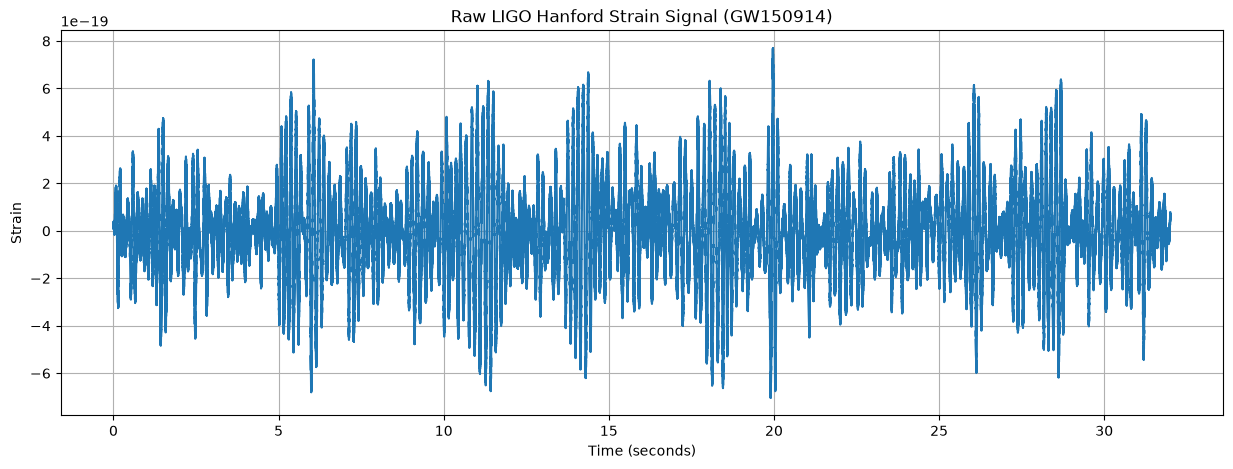

In [17]:
plt.figure(figsize=(15,5))

plt.plot(time, strain)

plt.xlabel("Time (seconds)")
plt.ylabel("Strain")

plt.title("Raw LIGO Hanford Strain Signal (GW150914)")

plt.grid(True)

plt.show()

In [18]:
print("Minimum :", np.min(strain))
print("Maximum :", np.max(strain))
print("Mean     :", np.mean(strain))
print("Std Dev  :", np.std(strain))

Minimum : -7.04466594316914e-19
Maximum : 7.706262192395323e-19
Mean     : -3.759448587146217e-23
Std Dev  : 2.18086907234423e-19


## Observations

- Detector: Hanford (H1)
- Recording duration: 32 seconds
- Sampling frequency: 4096 Hz
- Number of samples: 131072
- Data type: float64
- The raw signal appears dominated by detector noise.
- The gravitational wave is not visually obvious in the unprocessed data.
- Preprocessing will be required before feeding the signal into a CNN.

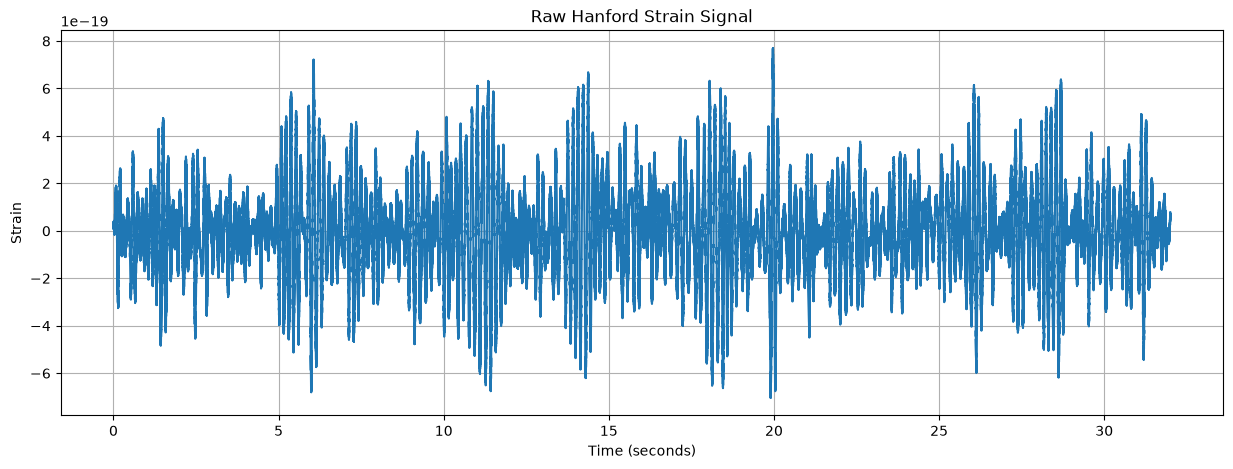

In [20]:
plt.figure(figsize=(15,5))

plt.plot(time, strain)

plt.xlabel("Time (seconds)")
plt.ylabel("Strain")

plt.title("Raw Hanford Strain Signal")

plt.grid(True)

plt.savefig(
    "../reports/figures/raw_h1_signal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Raw Signal Analysis

The raw Hanford strain signal spans 32 seconds and consists primarily of detector noise. The signal oscillates around zero with amplitudes on the order of 10⁻¹⁹.

Summary statistics:

- Minimum: -7.04 × 10⁻¹⁹
- Maximum: 7.71 × 10⁻¹⁹
- Mean: -3.76 × 10⁻²³
- Standard deviation: 2.18 × 10⁻¹⁹

No obvious gravitational-wave chirp is visible in the raw time series. This is expected because the detector output contains significant instrumental and environmental noise. Signal preprocessing is required before feature extraction and machine learning.